<a href="https://colab.research.google.com/github/Aryan005-coder/Ahoy-Compose-Chat/blob/main/product-localization-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving product-translation-ai-1000.zip to product-translation-ai-1000 (2).zip


In [22]:
import zipfile
with zipfile.ZipFile('product-translation-ai-1000.zip' , 'r') as z:
  z.extractall('data')

In [23]:
import os
os.listdir('data')

['product-translation-ai-1000.csv']

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv('data/product-translation-ai-1000.csv')
df.head()

,Index,Translation ID,Product Name,Category,Source Language,Target Language,Product Description,Feature Bullets,SEO Title,Translation Instructions,Glossary Terms,Do Not Translate
0,1,C3BqS1uC7a,Northline Adjustable Silicone Bib,Baby Products,English,Japanese,The Northline Adjustable Silicone Bib is desig...,dishwasher-safe material for everyday use | de...,Northline Adjustable Silicone Bib for Travel Days,Use natural ecommerce language. Keep the copy ...,dishwasher-safe material; deep front pocket; s...,Northline; Northline Adjustable Silicone Bib; ...
1,2,F65BzBDDaV,Northline Stainless Steel Espresso Machine,Kitchen Appliances,English,Japanese,The Northline Stainless Steel Espresso Machine...,removable drip tray for everyday use | 15-bar ...,Northline Stainless Steel Espresso Machine for...,Translate for an online store. Keep the benefi...,removable drip tray; 15-bar pump; brushed stee...,Northline; Northline Stainless Steel Espresso ...
2,3,8YOIESpcXG,Aster Minimalist Desk Lamp,Home Office,English,German,The Aster Minimalist Desk Lamp is designed for...,touch dimmer for everyday use | warm and cool ...,Aster Minimalist Desk Lamp for Compact Workspaces,Translate for an online store. Keep the benefi...,touch dimmer; warm and cool light modes; frost...,Aster; Aster Minimalist Desk Lamp; Model X100;...
3,4,PRYK806mYW,EverTrail Foldable Exercise Bike,Fitness Equipment,English,Spanish,The EverTrail Foldable Exercise Bike is design...,LCD training display for everyday use | magnet...,EverTrail Foldable Exercise Bike for Small Apa...,Translate for an online store. Keep the benefi...,LCD training display; magnetic resistance; pow...,EverTrail; EverTrail Foldable Exercise Bike; M...
4,5,7p8M90CMZg,Milo & Co Dimmable Desk Lamp,Home Office,English,Japanese,The Milo & Co Dimmable Desk Lamp is designed f...,USB-C charging port for everyday use | warm an...,Milo & Co Dimmable Desk Lamp for Focused Writi...,Translate for a product listing. Keep measurem...,USB-C charging port; warm and cool light modes...,Milo & Co; Milo & Co Dimmable Desk Lamp; Model...


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Index                     1000 non-null   int64 
 1   Translation ID            1000 non-null   object
 2   Product Name              1000 non-null   object
 3   Category                  1000 non-null   object
 4   Source Language           1000 non-null   object
 5   Target Language           1000 non-null   object
 6   Product Description       1000 non-null   object
 7   Feature Bullets           1000 non-null   object
 8   SEO Title                 1000 non-null   object
 9   Translation Instructions  1000 non-null   object
 10  Glossary Terms            1000 non-null   object
 11  Do Not Translate          1000 non-null   object
dtypes: int64(1), object(11)
memory usage: 93.9+ KB


In [27]:
## Question 1: How are products distributed across categories?

df['Category'].value_counts()

,count
Category,
Beauty & Personal Care,144
Baby Products,135
Outdoor Gear,135
Fitness Equipment,129
Consumer Electronics,125
Home Office,120
Pet Supplies,117
Kitchen Appliances,95


In [28]:
df['Target Language'].value_counts()

,count
Target Language,
Spanish,138
Portuguese,135
Japanese,131
Dutch,124
French,122
German,121
Italian,115
Swedish,114


In [29]:
## Question 2: Is translation language coverage equal across categories?
df.groupby('Category')['Target Language'].nunique().sort_values(ascending = False)

,Target Language
Category,
Baby Products,8
Beauty & Personal Care,8
Consumer Electronics,8
Fitness Equipment,8
Home Office,8
Kitchen Appliances,8
Outdoor Gear,8
Pet Supplies,8


In [30]:
df.groupby('Translation ID')['Target Language'].nunique().sort_values(ascending = False)

,Target Language
Translation ID,
zw5Ue4GMkt,1
00G7Fh1s7E,1
0135yNpUxS,1
01cj8nLeMp,1
02Sl9s0raF,1
...,...
0pbXG34FTr,1
0pGU8UeGZm,1
0kvxvNOcfO,1


In [31]:
df['Translation ID'].value_counts()

,count
Translation ID,
PXxlTbKyTD,1
C3BqS1uC7a,1
F65BzBDDaV,1
8YOIESpcXG,1
PRYK806mYW,1
...,...
4xKx4eyat3,1
SbQ8bNC3GO,1
8nSrT5hBQh,1


In [32]:
import matplotlib.pyplot as plt

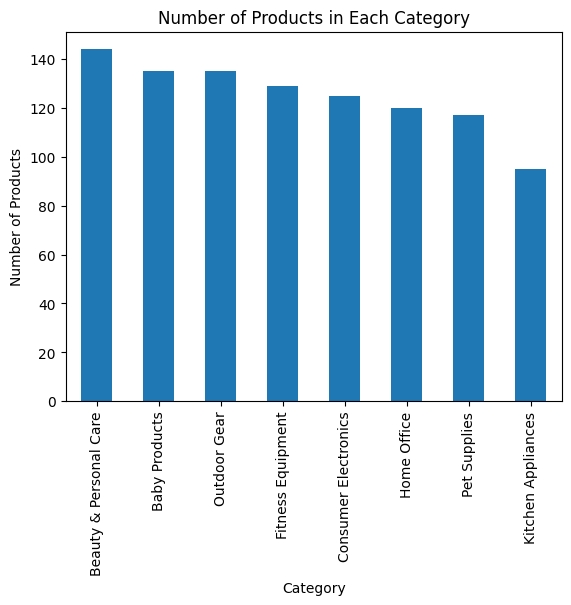

In [33]:
df['Category'].value_counts().plot(kind = 'bar')
plt.title('Number of Products in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.show()

In [34]:
## Question 3: Does translation effort (description length) vary by category?
df['Description Length'] = df['Product Description'].str.len()
df.groupby('Category')['Description Length'].mean().sort_values(ascending = False)

,Description Length
Category,
Kitchen Appliances,410.936842
Fitness Equipment,407.922481
Consumer Electronics,406.024000
Home Office,402.716667
Outdoor Gear,400.725926
Baby Products,397.829630
Pet Supplies,396.948718
Beauty & Personal Care,395.333333


In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Index                     1000 non-null   int64 
 1   Translation ID            1000 non-null   object
 2   Product Name              1000 non-null   object
 3   Category                  1000 non-null   object
 4   Source Language           1000 non-null   object
 5   Target Language           1000 non-null   object
 6   Product Description       1000 non-null   object
 7   Feature Bullets           1000 non-null   object
 8   SEO Title                 1000 non-null   object
 9   Translation Instructions  1000 non-null   object
 10  Glossary Terms            1000 non-null   object
 11  Do Not Translate          1000 non-null   object
 12  Description Length        1000 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 101.7+ KB


In [35]:
## ConclusionProduct volume varies substantially across categories (95–144 products), but translation effort per item — measured by description length — stays remarkably consistent (~395–411 characters) and language coverage is uniform (all 8 categories translated into all 8 languages). This means translation workload is driven by catalog size, not inconsistent depth or neglect of any category.